# 📊 Qlib + Colab：沪深300完整因子 → 回测 → 可视化

**环境**：Google Colab（CPU）  
**股票池**：沪深300（CSI300）  
**流程**：因子构造 → 回测 → 可视化分析


## 0️⃣ 环境准备

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
!pip install -q pyqlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import qlib
print(qlib.__version__)


0.9.7


## 1️⃣ 下载并初始化 Qlib 数据

In [4]:
!wget https://github.com/chenditc/investment_data/releases/latest/download/qlib_bin.tar.gz
!mkdir -p ~/.qlib/qlib_data/cn_data
!tar -zxvf qlib_bin.tar.gz -C ~/.qlib/qlib_data/cn_data --strip-components=1
!rm -f qlib_bin.tar.gz

'wget' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���
�����﷨����ȷ��
tar: Error opening archive: Failed to open 'qlib_bin.tar.gz'
'rm' �����ڲ����ⲿ���Ҳ���ǿ����еĳ���
���������ļ���


In [5]:
# use default data

import qlib
import pandas as pd
from qlib.constant import REG_CN
from qlib.utils import exists_qlib_data, init_instance_by_config
from qlib.workflow import R
from qlib.workflow.record_temp import SignalRecord, PortAnaRecord
from qlib.utils import flatten_dict

provider_uri = "~/.qlib/qlib_data/cn_data"  # target_dir
if not exists_qlib_data(provider_uri):
    print(f"Qlib data is not found in {provider_uri}")
    sys.path.append(str(scripts_dir))
    from get_data import GetData

    GetData().qlib_data(target_dir=provider_uri, region=REG_CN)
qlib.init(provider_uri=provider_uri, region=REG_CN)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[11716:MainThread](2026-04-04 11:01:43,972) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[11716:MainThread](2026-04-04 11:01:43,978) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[11716:MainThread](2026-04-04 11:01:43,979) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('C:/Users/Yongj/.qlib/qlib_data/cn_data')}


## 2️⃣ 定义股票池（沪深300）

In [6]:
market = "csi300"
benchmark = "SH000300"

In [7]:
# 打印最新的行情
from qlib.data import D
import pandas as pd

symbol = "SH600519"  # 贵州茅台
fields = ['$open', '$high', '$low', '$close', '$volume']

df = D.features(
    instruments=[symbol],
    fields=fields,
    freq="day"
)
print(df.head(1))
print(df.tail(1))

                          $open     $high      $low  $close    $volume
instrument datetime                                                   
SH600519   2005-01-04  0.998628  1.009602  0.987654     1.0  85614.125
                            $open       $high        $low      $close  \
instrument datetime                                                     
SH600519   2025-12-30  199.646408  199.774658  197.508865  198.038971   

                            $volume  
instrument datetime                  
SH600519   2025-12-30  237131.78125  


In [8]:
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

today = date.today()
latest_date = today - timedelta(days=1)

# ===== test：最近 3 个自然月 =====
test_start = (latest_date - relativedelta(months=2)).replace(day=1)
test_end = latest_date

# ===== valid：test 前至少 6 个自然月 =====
valid_end = test_start - timedelta(days=1)
valid_start = (valid_end - relativedelta(months=5)).replace(day=1)

# ===== train：剩余全部历史 =====
train_start = date(2022, 1, 1)
train_end = valid_start - timedelta(days=1)

print(f"train: {train_start.isoformat()} - {train_end.isoformat()}")
print(f"valid: {valid_start.isoformat()} - {valid_end.isoformat()}")
print(f"test: {test_start.isoformat()} - {test_end.isoformat()}")

train: 2022-01-01 - 2025-07-31
valid: 2025-08-01 - 2026-01-31
test: 2026-02-01 - 2026-04-03


In [9]:
###################################
# train model
###################################
data_handler_config = {
    "start_time": "2022-01-01",
    "end_time": "2025-12-22",
    "fit_start_time": "2022-01-01",
    "fit_end_time": "2024-12-31",
    "instruments": market,
}

task = {
    "model": {
        "class": "LGBModel",
        "module_path": "qlib.contrib.model.gbdt",
        "kwargs": {
            "loss": "mse",
            "colsample_bytree": 0.8879,
            "learning_rate": 0.0421,
            "subsample": 0.8789,
            "lambda_l1": 205.6999,
            "lambda_l2": 580.9768,
            "max_depth": 8,
            "num_leaves": 210,
            "num_threads": 20,
        },
    },
    "dataset": {
        "class": "DatasetH",
        "module_path": "qlib.data.dataset",
        "kwargs": {
            "handler": {
                "class": "Alpha158",
                "module_path": "qlib.contrib.data.handler",
                "kwargs": data_handler_config,
            },
            "segments": {
                "train": (train_start.isoformat(), train_end.isoformat()),
                "valid": (valid_start.isoformat(), valid_end.isoformat()),
                "test": (test_start.isoformat(), test_end.isoformat()),
            },
        },
    },
}

# model initialization
model = init_instance_by_config(task["model"])
dataset = init_instance_by_config(task["dataset"])

# start exp to train model
with R.start(experiment_name="train_model"):
    R.log_params(**flatten_dict(task))
    model.fit(dataset)
    R.save_objects(trained_model=model)
    rid = R.get_recorder().id

ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)
ModuleNotFoundError. XGBModel is skipped(optional: maybe installing xgboost can fix it).
ModuleNotFoundError.  PyTorch models are skipped (optional: maybe installing pytorch can fix it).


[11716:MainThread](2026-04-04 11:02:28,712) INFO - qlib.timer - [log.py:127] - Time cost: 39.205s | Loading data Done
[11716:MainThread](2026-04-04 11:02:29,027) INFO - qlib.timer - [log.py:127] - Time cost: 0.056s | DropnaLabel Done
[11716:MainThread](2026-04-04 11:02:29,462) INFO - qlib.timer - [log.py:127] - Time cost: 0.435s | CSZScoreNorm Done
[11716:MainThread](2026-04-04 11:02:29,467) INFO - qlib.timer - [log.py:127] - Time cost: 0.754s | fit & process data Done
[11716:MainThread](2026-04-04 11:02:29,469) INFO - qlib.timer - [log.py:127] - Time cost: 39.962s | Init data Done
c:\AI_Workspace\qi-flow\venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance

Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.993543	valid's l2: 0.997798
[40]	train's l2: 0.990744	valid's l2: 0.998797
Early stopping, best iteration is:
[1]	train's l2: 0.996485	valid's l2: 0.99674


[11716:MainThread](2026-04-04 11:02:31,780) INFO - qlib.timer - [log.py:127] - Time cost: 0.067s | waiting `async_log` Done


In [11]:
###################################
# prediction, backtest & analysis
###################################
port_analysis_config = {
    "executor": {
        "class": "SimulatorExecutor",
        "module_path": "qlib.backtest.executor",
        "kwargs": {
            "time_per_step": "day",
            "generate_portfolio_metrics": True,
        },
    },
    "strategy": {
        "class": "TopkDropoutStrategy",
        "module_path": "qlib.contrib.strategy.signal_strategy",
        "kwargs": {
            "model": model,
            "dataset": dataset,
            "topk": 5,
            "n_drop": 1,
        },
    },
    "backtest": {
        "start_time": test_start.isoformat(),
        "end_time":  test_end.isoformat(),
        "account": 500000,
        "benchmark": benchmark,
        "exchange_kwargs": {
            "freq": "day",
            "limit_threshold": 0.095,
            "deal_price": "close",
            "open_cost": 0.0005,
            "close_cost": 0.0015,
            "min_cost": 5,
        },
    },
}

# backtest and analysis
with R.start(experiment_name="backtest_analysis"):
    recorder = R.get_recorder(recorder_id=rid, experiment_name="train_model")
    model = recorder.load_object("trained_model")

    # prediction
    recorder = R.get_recorder()
    ba_rid = recorder.id
    sr = SignalRecord(model, dataset, recorder)
    sr.generate()

    # backtest & analysis
    par = PortAnaRecord(recorder, port_analysis_config, "day")
    par.generate()

[11716:MainThread](2026-04-04 11:17:23,718) INFO - qlib.workflow - [exp.py:258] - Experiment 492556851795562616 starts running ...
[11716:MainThread](2026-04-04 11:17:23,739) INFO - qlib.workflow - [recorder.py:345] - Recorder 2c00a0a9486e4dc6881f0183cc6cec88 starts running under Experiment 492556851795562616 ...


[11716:MainThread](2026-04-04 11:17:24,193) INFO - qlib.workflow - [record_temp.py:198] - Signal record 'pred.pkl' has been saved as the artifact of the Experiment 492556851795562616


'The following are prediction results of the LGBModel model.'
Empty DataFrame
Columns: [score]
Index: []


[11716:MainThread](2026-04-04 11:17:24,240) INFO - qlib.timer - [log.py:127] - Time cost: 0.000s | waiting `async_log` Done


ValueError: The benchmark ['SH000300'] does not exist. Please provide the right benchmark

In [ ]:
import pandas as pd
import os

recorder = R.get_recorder(recorder_id=ba_rid, experiment_name="backtest_analysis")
portfolio_analysis_dir = recorder.client.download_artifacts(recorder.id, "portfolio_analysis")
positions_path = os.path.join(portfolio_analysis_dir, "positions_normal_1day.pkl")
positions_df = pd.read_pickle(positions_path)
last_day_info = list(positions_df.values())[-1]

# The 'position' attribute of last_day_info is the dictionary containing all assets
portfolio_details = last_day_info.position

position_data = []

# Add Cash information
if 'cash' in portfolio_details:
    position_data.append({
        'Asset': 'Cash',
        'Amount': portfolio_details['cash'],
        'Price': None,
        'Weight': None,
        'Count Day': None
    })

# Add Total Account Value
if 'now_account_value' in portfolio_details:
    position_data.append({
        'Asset': 'Total Account Value',
        'Amount': portfolio_details['now_account_value'],
        'Price': None,
        'Weight': None,
        'Count Day': None
    })

# Iterate over individual stock positions
for asset, details in portfolio_details.items():
    # Skip 'cash' and 'now_account_value' as they are handled separately
    if asset not in ['cash', 'now_account_value'] and isinstance(details, dict):
        position_data.append({
            'Asset': asset,
            'Amount': details.get('amount'),
            'Price': details.get('price'),
            'Weight': details.get('weight'),
            'Count Day': details.get('count_day')
        })

# Print last date
print(list(positions_df.keys())[-1])
# Create a DataFrame from the extracted data
position_table = pd.DataFrame(position_data)
display(position_table)

2026-03-05 00:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Asset,Amount,Price,Weight,Count Day
0,Cash,500000.0,None,None,None
1,Total Account Value,500000.0,None,None,None


In [ ]:
# import yfinance as yf
# import time

# # 删除 Asset 列为 NaN 的行
# position_table = position_table.dropna(subset=["Price"])

# # 转换为 Yahoo Finance 格式
# def to_yahoo(code):
#     if code.startswith("SZ"):
#         return code[2:] + ".SZ"
#     elif code.startswith("SH"):
#         return code[2:] + ".SS"
#     else:
#         return code

# # 获取股票简称
# def get_name(code):
#     yahoo_code = to_yahoo(code)
#     try:
#         ticker = yf.Ticker(yahoo_code)
#         info = ticker.info
#         name = info.get("shortName") or info.get("longName") or code
#         time.sleep(0.1)  # 防止被限流
#         return name
#     except Exception:
#         return code

# # 新增列 name
# position_table["name"] = position_table["Asset"].apply(get_name)

# # 查看结果
# position_table



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Asset,Amount,Price,Weight,Count Day,name


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


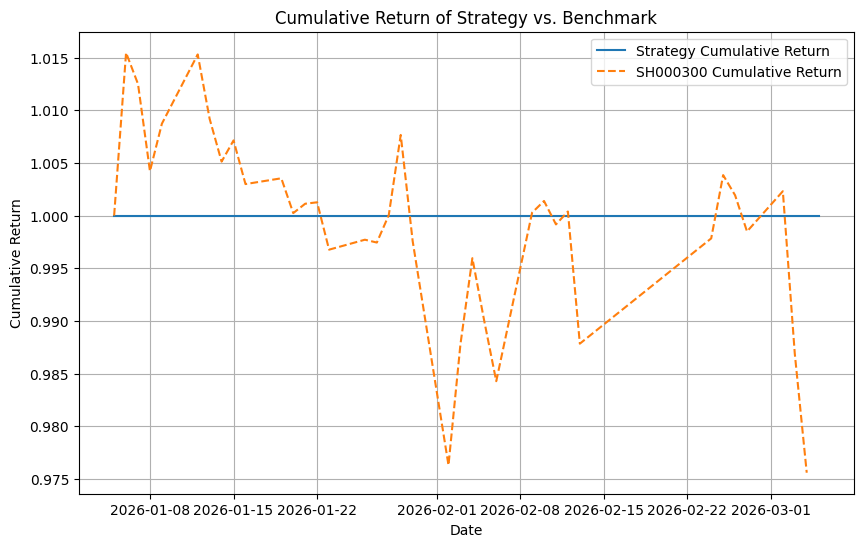

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import matplotlib.pyplot as plt
import qlib
import pandas as pd
from qlib.data import D # Import D from qlib.data

# Load the portfolio metrics
recorder = R.get_recorder(recorder_id=ba_rid, experiment_name="backtest_analysis")
portfolio_analysis_dir = recorder.client.download_artifacts(recorder.id, "portfolio_analysis")
portfolio_metrics_path = os.path.join(portfolio_analysis_dir, "report_normal_1day.pkl")
portfolio_metrics = pd.read_pickle(portfolio_metrics_path)

# Calculate cumulative returns for the strategy
strategy_cum_return = (1 + portfolio_metrics["return"]).cumprod()

# Get benchmark data
# Define the backtest period from the port_analysis_config
backtest_start_time = port_analysis_config["backtest"]["start_time"]
backtest_end_time = port_analysis_config["backtest"]["end_time"]

# Fetch benchmark prices using D.features
benchmark_df = D.features(
    instruments=[benchmark],
    fields=["$close"],
    start_time=backtest_start_time,
    end_time=backtest_end_time,
    freq="day"
)
# Extract the 'close' price series from the MultiIndex DataFrame
# The column name in D.features is '$close', not 'close'
# Corrected indexing: benchmark is the first level of the row index
benchmark_price_series = benchmark_df.loc[benchmark, '$close']

# Calculate benchmark daily returns and then cumulative returns
benchmark_daily_return = benchmark_price_series.pct_change().fillna(0)
benchmark_cum_return = (1 + benchmark_daily_return).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(strategy_cum_return, label="Strategy Cumulative Return")
plt.plot(benchmark_cum_return, label=f"{benchmark} Cumulative Return", linestyle="--")
plt.title("Cumulative Return of Strategy vs. Benchmark")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()